## Load Required Libraries

This cell imports the main Python libraries used for data handling, numerical operations, and visualisation.

- `pandas` is used to load and manipulate the cleaned dataset.
- `numpy` is used for numerical calculations, especially RMSE and cyclical month features.
- `matplotlib.pyplot` is used to plot model validation results and residuals.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Set Data Folder Path

This cell defines the folder where the cleaned modelling dataset is stored.

The cleaned file we are using is `prediction_data.csv`, located inside the `Data_Clean` folder.

In [2]:
# Update these paths to match your folder structure
DATA_DIR = "C:\HACKTHONS\POLYGLOTY\Hackathon_PolyglotPioneers\Data_Clean"

<>:2: SyntaxWarning: invalid escape sequence '\H'
<>:2: SyntaxWarning: invalid escape sequence '\H'
C:\Users\MokopakgosiOgaufi\AppData\Local\Temp\ipykernel_88172\3881167667.py:2: SyntaxWarning: invalid escape sequence '\H'
  DATA_DIR = "C:\HACKTHONS\POLYGLOTY\Hackathon_PolyglotPioneers\Data_Clean"


## Load Cleaned Prediction Dataset

This cell loads the cleaned monthly modelling dataset.

The dataset already contains merged variables from FAO food prices, Baltic Dry Index features, Brent crude oil prices, and Botswana policy rate data.

In [3]:
prediction = pd.read_csv(f"{DATA_DIR}/prediction_data.csv")
prediction.head()

,year_month,FAO_23012,FAO_23013,FAO_23014,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate
0,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0
1,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0
2,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0
3,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0
4,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0


## Inspect Dataset Structure

This cell checks the dataset columns, data types, and missing values.

This helps confirm that the cleaned dataset is ready for modelling and that no important variables are missing.

In [4]:
prediction.info()

<class 'pandas.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year_month            276 non-null    str    
 1   FAO_23012             276 non-null    float64
 2   FAO_23013             276 non-null    float64
 3   FAO_23014             276 non-null    float64
 4   BDI_std               276 non-null    float64
 5   first                 276 non-null    int64  
 6   last                  276 non-null    int64  
 7   monthly_return_bdi    276 non-null    float64
 8   Brent_USD_per_barrel  276 non-null    float64
 9   policy_rate           276 non-null    float64
dtypes: float64(7), int64(2), str(1)
memory usage: 23.6 KB


## Prepare Date Column and Define Target Variable

This cell converts the `year_month` column into a proper date column so the data can be sorted chronologically.

The target variable is `FAO_23014`, which represents food price inflation. This is the variable the model will learn to predict.

In [5]:
prediction["date"] = pd.to_datetime(prediction["year_month"] + "-01")
prediction = prediction.sort_values("date").reset_index(drop=True)

TARGET = "FAO_23014"

prediction.head()

,year_month,FAO_23012,FAO_23013,FAO_23014,BDI_std,first,last,monthly_return_bdi,Brent_USD_per_barrel,policy_rate,date
0,2001-01,34.291207,33.061978,3.602384,29.297289,1599,1504,-0.059412,25.62,14.0,2001-01-01
1,2001-02,34.341562,33.243495,3.359312,29.086577,1493,1537,0.029471,27.50,14.0,2001-02-01
2,2001-03,34.643687,33.295356,2.720000,24.971716,1538,1438,-0.065020,24.50,14.0,2001-03-01
3,2001-04,34.794749,33.321287,2.173337,16.162009,1430,1459,0.020280,25.66,14.0,2001-04-01
4,2001-05,35.273114,33.476873,2.028451,26.959493,1453,1389,-0.044047,28.31,14.0,2001-05-01


## Create Lag and Time-Based Features

This function creates lag features for the target and explanatory variables.

Lag features allow the model to use past values to predict future food inflation. This is important because inflation usually has persistence, meaning previous months can help explain future months.

The selected lags are:
- 1 month for short-term effects
- 3 months for quarterly effects
- 6 months for medium-term pass-through effects
- 12 months for yearly or seasonal patterns

The function also creates:
- `month`
- `quarter`
- `month_sin`
- `month_cos`
- rolling food inflation averages

The sine and cosine month features help the model understand seasonality without treating months as simple numbers.

In [6]:
def add_lag_features(df):
    df = df.copy()

    lag_config = {
        "FAO_23014": [1, 3, 6, 12],
        "FAO_23013": [1, 3, 6, 12],
        "FAO_23012": [1, 3, 6, 12],
        "BDI_std": [1, 3, 6],
        "monthly_return_bdi": [1, 3, 6],
        "Brent_USD_per_barrel": [1, 3, 6],
        "policy_rate": [1, 3, 6, 12],
    }

    for col, lags in lag_config.items():
        for lag in lags:
            df[f"{col}_lag_{lag}"] = df[col].shift(lag)

    df["month"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    df["food_inflation_roll_mean_3"] = df[TARGET].shift(1).rolling(3).mean()
    df["food_inflation_roll_mean_6"] = df[TARGET].shift(1).rolling(6).mean()
    df["food_inflation_roll_mean_12"] = df[TARGET].shift(1).rolling(12).mean()

    return df

## Apply Feature Engineering

This cell applies the lag feature function to the cleaned dataset.

Rows with missing values are dropped because lag features naturally create missing values at the beginning of the time series. For example, a 12-month lag cannot exist for the first 12 months.

In [7]:
model_data = add_lag_features(prediction)
model_data = model_data.dropna().reset_index(drop=True)

model_data.shape

(264, 43)

## Import Modelling Tools

This cell imports the machine learning tools needed for the statistical baseline model.

We use `HistGradientBoostingRegressor`, a gradient boosting tree model. It is treated as the classical/statistical baseline because it is not a deep learning model and works well with structured tabular features.

RMSE is used as the evaluation metric because the hackathon requires model comparison using prediction error.

In [8]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

## Split Data Into Training and Validation Sets

This cell separates the dataset into features and target values.

The last 24 months are used as the validation set. This is appropriate for time-series forecasting because the model is trained on the past and tested on later unseen months.

We do not randomly shuffle the data because that would break the time order and could cause data leakage.

In [9]:
drop_cols = ["year_month", "date", TARGET, "first", "last"]
feature_cols = [col for col in model_data.columns if col not in drop_cols]

train = model_data.iloc[:-24]
valid = model_data.iloc[-24:]

X_train = train[feature_cols]
y_train = train[TARGET]

X_valid = valid[feature_cols]
y_valid = valid[TARGET]

## Train Gradient Boosting Statistical Model

This cell trains the statistical baseline model.

The model learns relationships between past food inflation, price indices, shipping-cost features, oil prices, policy rates, and future food inflation.

The chosen model is Gradient Boosting Trees because it can capture non-linear relationships and interactions between variables without requiring deep learning.

In [10]:
gbt_model = HistGradientBoostingRegressor(
    max_iter=500,
    learning_rate=0.03,
    l2_regularization=0.1,
    random_state=42
)

gbt_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'squared_error'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",500
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.1
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged::

## Evaluate Model Using RMSE

This cell uses the trained model to predict food inflation for the validation period.

The predictions are compared with the actual food inflation values using RMSE.

A lower RMSE means the model predictions are closer to the actual values.

In [11]:
valid_preds = gbt_model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
rmse

np.float64(2.1584150662856825)

## Plot Actual vs Predicted Food Inflation

This chart compares actual food inflation with the model's predicted values over the validation period.

If the predicted line follows the actual line closely, it means the model is capturing the main food inflation trend.

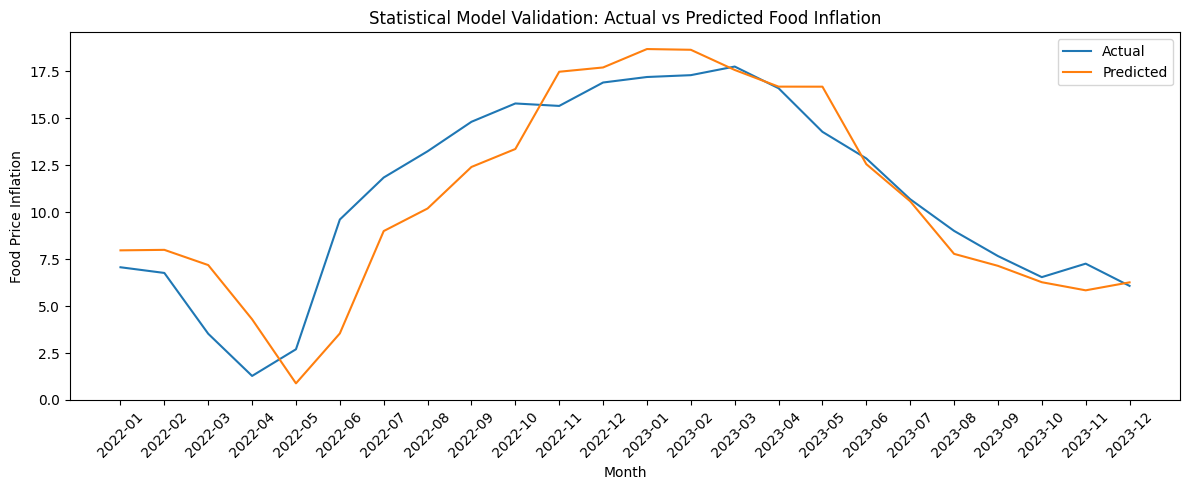

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(valid["year_month"], y_valid, label="Actual")
plt.plot(valid["year_month"], valid_preds, label="Predicted")
plt.xticks(rotation=45)
plt.title("Statistical Model Validation: Actual vs Predicted Food Inflation")
plt.xlabel("Month")
plt.ylabel("Food Price Inflation")
plt.legend()
plt.tight_layout()
plt.show()

## Residual Diagnostics

This cell calculates and plots the residuals.

Residuals are the difference between the actual values and predicted values.

Residual = Actual food inflation - Predicted food inflation

A good model should have residuals that are centered around zero, without a strong visible pattern.

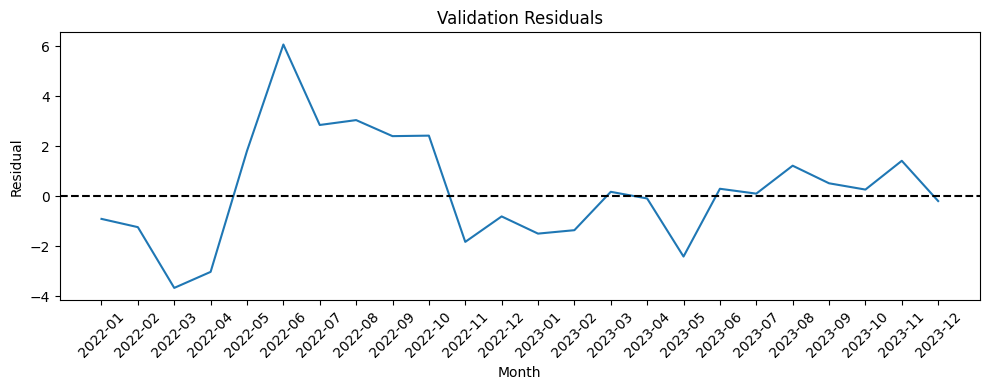

Residual mean: 0.23728587638523868
Residual std: 2.191473836700561


In [13]:
residuals = y_valid - valid_preds

plt.figure(figsize=(10, 4))
plt.plot(valid["year_month"], residuals)
plt.axhline(0, color="black", linestyle="--")
plt.xticks(rotation=45)
plt.title("Validation Residuals")
plt.xlabel("Month")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())